In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn import (
    calibration,
    linear_model,
    metrics,
    model_selection,
    neighbors,
    preprocessing,
    svm,
)

pd.set_option("display.float_format", "{:.2f}".format)

## Часть 1. Работа с датасетом

### Первоначальный анализ данных

In [2]:
df = pd.read_csv("data/bank_clients.csv")

display(df.info())
display(df.describe())
display(df.describe(include="object"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        2509 non-null   int64  
 1   CustomerId       2509 non-null   int64  
 2   Surname          2509 non-null   object 
 3   CreditScore      2509 non-null   int64  
 4   Geography        2509 non-null   object 
 5   Gender           2509 non-null   object 
 6   Age              2509 non-null   int64  
 7   Tenure           2509 non-null   int64  
 8   Balance          2509 non-null   float64
 9   NumOfProducts    2509 non-null   int64  
 10  HasCrCard        2509 non-null   int64  
 11  IsActiveMember   2509 non-null   int64  
 12  EstimatedSalary  2509 non-null   float64
 13  Exited           2509 non-null   int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 274.6+ KB


None

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00,2509.00
mean,5000.28,15690555.65,651.45,39.77,5.01,119730.12,1.52,0.71,0.50,101113.44,0.32
std,2918.98,73228.43,98.17,10.52,2.94,27022.01,0.62,0.45,0.50,58263.01,0.47
min,8.00,15565779.00,350.00,18.00,0.00,27288.43,1.00,0.00,0.00,11.58,0.00
25%,2461.00,15627395.00,584.00,32.00,2.00,102800.72,1.00,0.00,0.00,51016.02,0.00
50%,4997.00,15689886.00,651.00,38.00,5.00,119703.10,1.00,1.00,0.00,102397.22,0.00
75%,7583.00,15755731.00,722.00,45.00,8.00,137560.38,2.00,1.00,1.00,151083.80,1.00
max,9999.00,15815656.00,850.00,84.00,10.00,214346.96,4.00,1.00,1.00,199970.74,1.00


,Surname,Geography,Gender
count,2509,2509,2509
unique,1330,1,2
top,Martin,Germany,Male
freq,11,2509,1316


In [3]:
dupl = df.duplicated().sum()
print(f"Дубликатов в данных: {dupl}")

if dupl:
    df = df.drop_duplicates()


uninfo_features = ["RowNumber", "CustomerId", "Surname", "Geography"]
df = df.drop(columns=uninfo_features)

target_col = "Exited"
feature_cols = ", ".join(col for col in df.columns)
print("Оставшиеся признаки:", feature_cols)

Дубликатов в данных: 0
Оставшиеся признаки: CreditScore, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited


In [4]:
df["NumOfProducts"].value_counts(normalize=True).round(4)*100

NumOfProducts
1   53.77
2   41.45
3    3.83
4    0.96
Name: proportion, dtype: float64

**Вывод:**  
Пропущенных значений или дубликатов данных не обнаружено. Среднее значение целевой переменной `0.32` говорит о дисбалансе классов. Все клиенты из одной страны - Германия. Большинство клиентов имеет 1-2 продукта, 3 или 4 очень редкие события.

Неинформативные признаки: `RowNumber`, `CustomerId`, `Geography`, `Surname`

### Распределения признаков

Exited
0   67.56
1   32.44
Name: proportion, dtype: float64

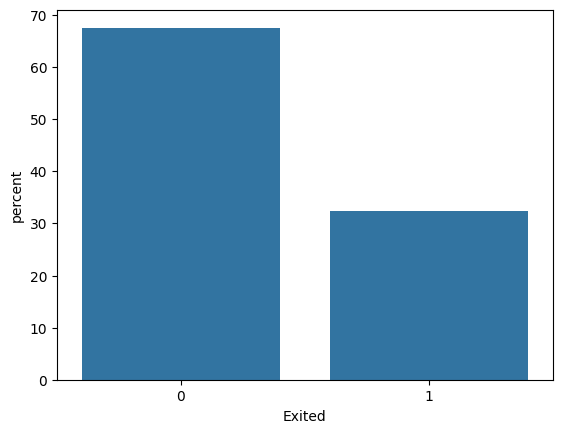

In [5]:
sns.countplot(data=df, x=target_col, stat="percent")

display(df[target_col].value_counts(normalize=True).round(4)*100)

Статистика для CreditScore:
Среднее: 651.45
Стандартное отклонение: 98.17
Скос: -0.08
Смещение: -0.45
Нормальность распределения: 0.99

Статистика для Age:
Среднее: 39.77
Стандартное отклонение: 10.52
Скос: 0.84
Смещение: 0.94
Нормальность распределения: 0.96

Статистика для Tenure:
Среднее: 5.01
Стандартное отклонение: 2.94
Скос: 0.03
Смещение: -1.21
Нормальность распределения: 0.94

Статистика для Balance:
Среднее: 119730.12
Стандартное отклонение: 27022.01
Скос: -0.04
Смещение: 0.33
Нормальность распределения: 1.00

Статистика для NumOfProducts:
Среднее: 1.52
Стандартное отклонение: 0.62
Скос: 1.01
Смещение: 1.13
Нормальность распределения: 0.71

Статистика для EstimatedSalary:
Среднее: 101113.44
Стандартное отклонение: 58263.01
Скос: -0.00
Смещение: -1.21
Нормальность распределения: 0.95



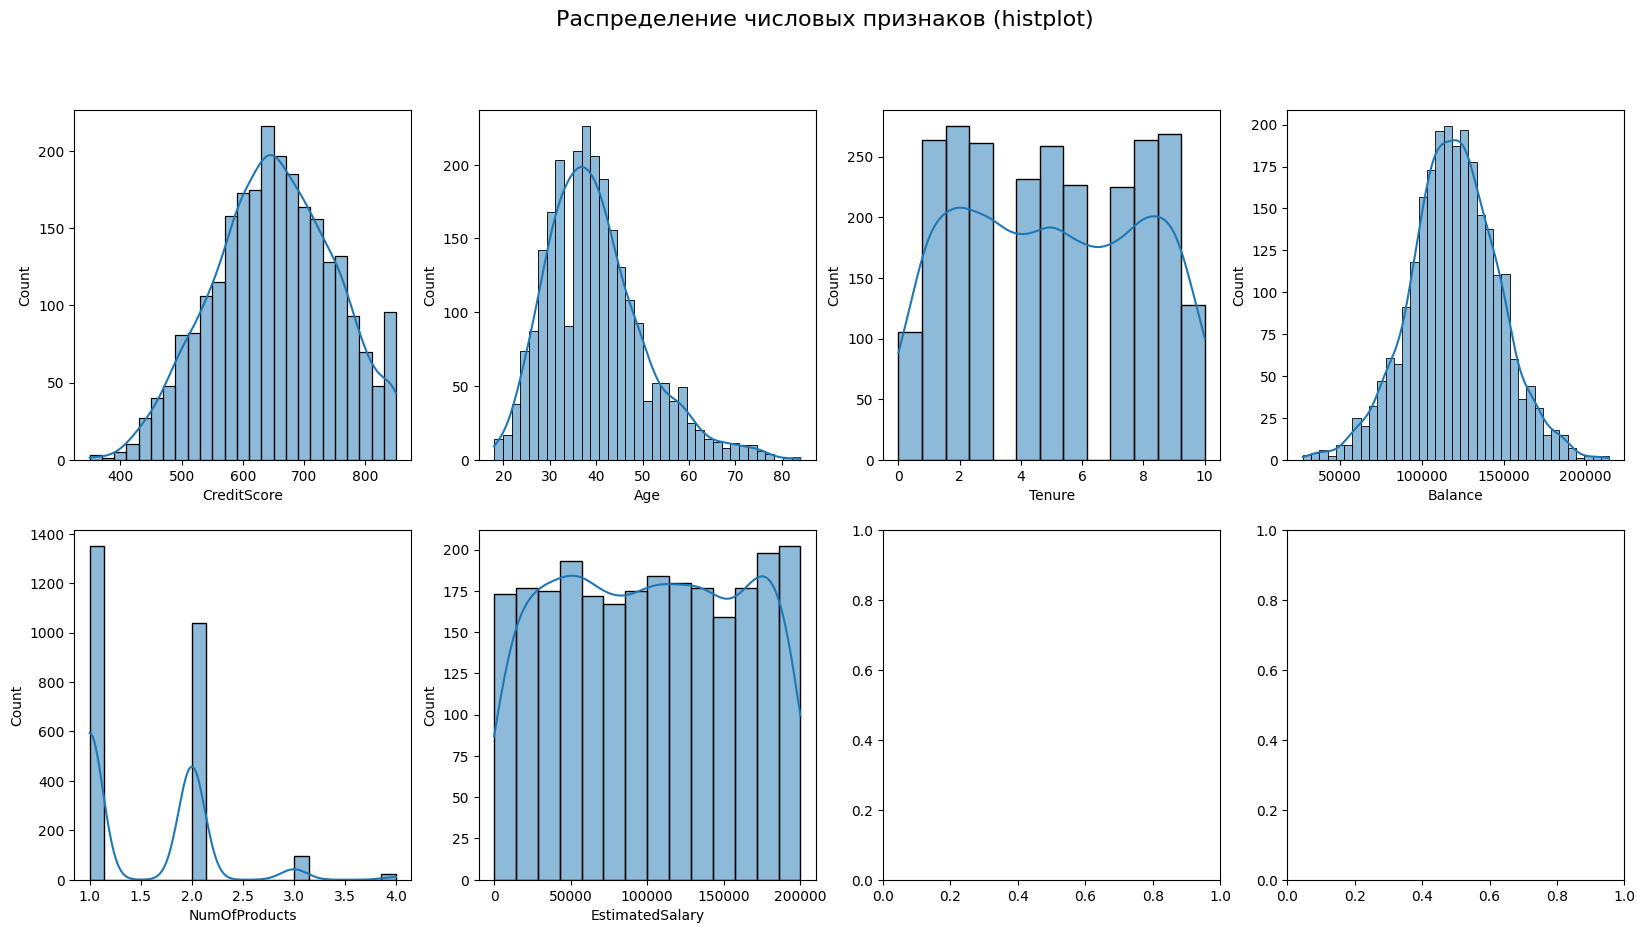

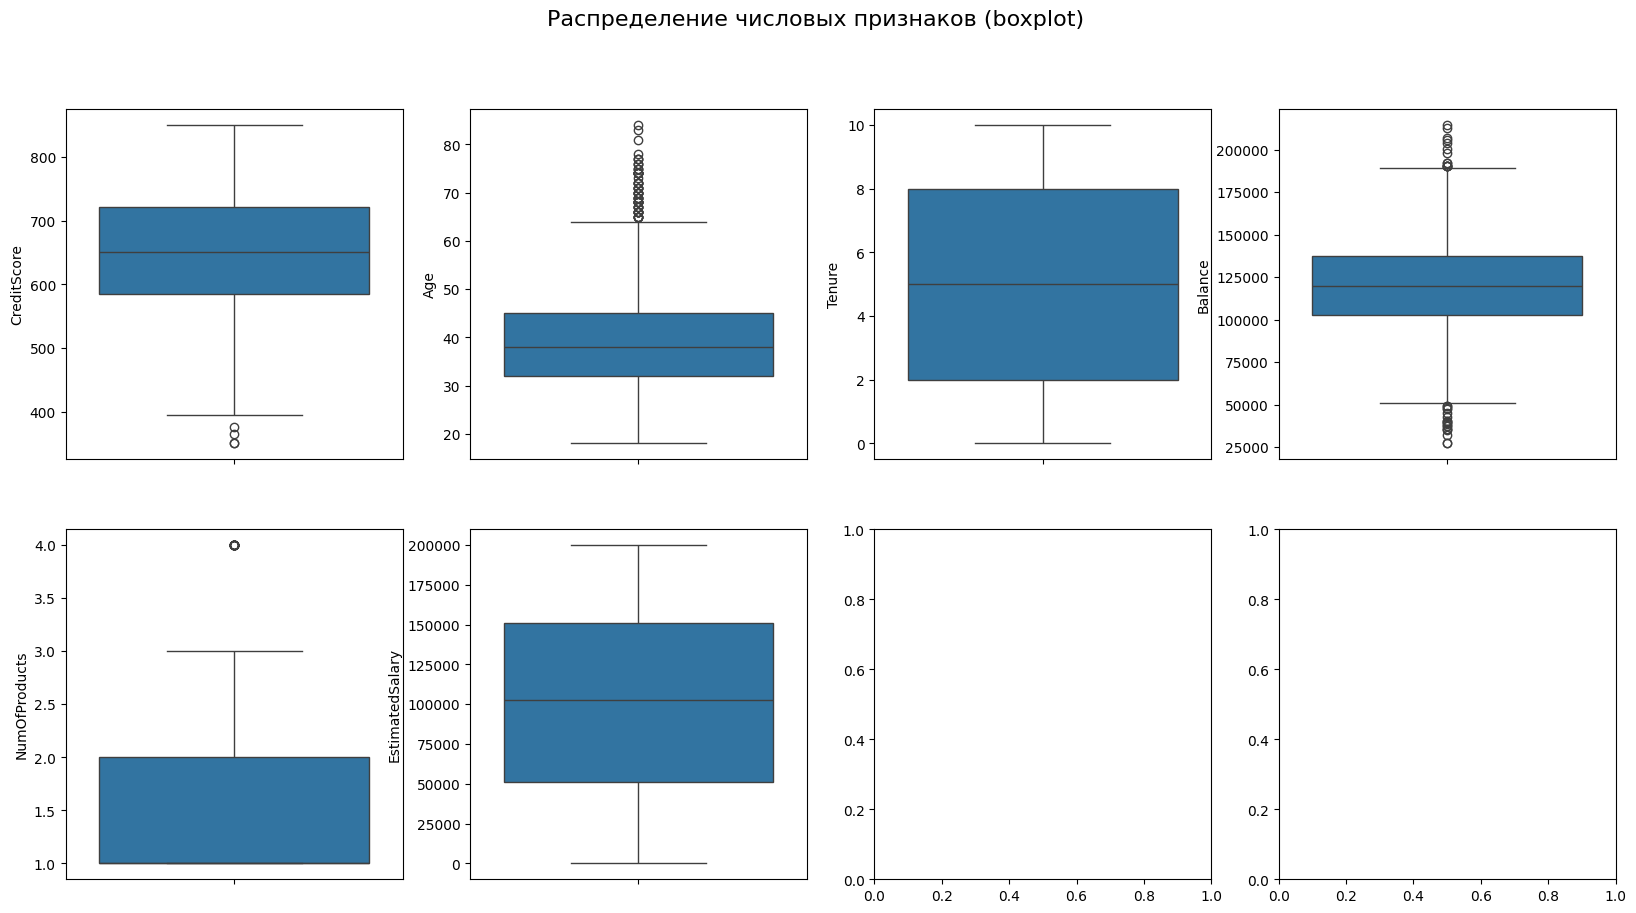

In [6]:
def plot_numerical_distributions(df: pd.DataFrame, cols_per_row: int = 4) -> None:
    """
    Строит histplot и boxplot для всех числовых колонок DataFrame
    """
    df_cols = df.columns
    n_cols = len(df_cols)
    rows = math.ceil(n_cols / cols_per_row)
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 5*rows))
    fig.suptitle("Распределение числовых признаков (histplot)", fontsize=16)

    axes = axes.flatten()
    
    for idx, col in enumerate(df_cols):
        ax = axes[idx]
        sns.histplot(data=df, x=col, ax=ax, kde=True)
        
        mean = df[col].mean()
        std = df[col].std()
        skew = df[col].skew()
        kurt = df[col].kurt()
        norm = stats.shapiro(df[col])
        print(
            f"Статистика для {col}:\n"
            f"Среднее: {mean:.2f}\n"
            f"Стандартное отклонение: {std:.2f}\n"
            f"Скос: {skew:.2f}\n"
            f"Смещение: {kurt:.2f}\n"
            f"Нормальность распределения: {norm.statistic:.2f}\n"
        )
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 5*rows))
    fig.suptitle("Распределение числовых признаков (boxplot)", fontsize=16)
    axes = axes.flatten()
    
    for idx, col in enumerate(df_cols):
        ax = axes[idx]
        sns.boxplot(data=df, y=col, ax=ax)

num_cols = [
    "CreditScore", "Age", "Tenure",
    "Balance", "NumOfProducts", "EstimatedSalary",
]
plot_numerical_distributions(df[num_cols])

**Вывод:**  
- в распределении целевой переменной `Exited` наблюдается дисбаланс классов: примерно 70% клиентов остались, остальные 30% ушли (мягкий дисбаланс классов).
- `CreditScore`, `Balance`, `EstimatedSalary`, `Tenure` имеют распределения, близкие к нормальным; `Age` - правосторонний скос (больше молодых клиентов);
- `NumOfProducts` - сильный положительный скос, 4 продукта имеют менее 1% клиентов в данных

### Матрица корреляций и мультиколлинеарность

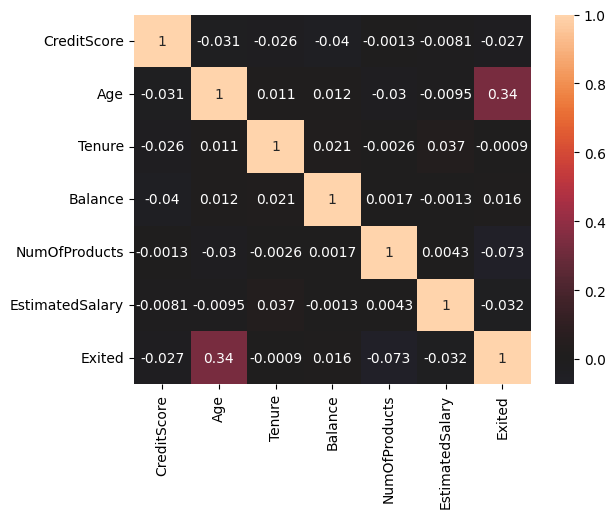

In [7]:
num_cols.append(target_col)
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, center=0.0, annot=True)

plt.show()

**Вывод:**  
Среди числовых признаков, только `Age` имеет более-менее значимую корреляцию с целевым признаком `(0.34)`; остальные имеют слабую линейную связь `(<0.1)` (возможно, связь нелинейна или требует создания новых признаков их комбинацией).

### Создание новых признаков

In [8]:
df["BalanceSalaryRatio"] = df["Balance"] / df["EstimatedSalary"]

df["TenureByAge"] = df["Tenure"] / df["Age"]

df["CreditScoreGivenAge"] = df["CreditScore"] / df["Age"]

new_cols = ["BalanceSalaryRatio", "TenureByAge", "CreditScoreGivenAge"]
df[new_cols].describe()

,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
count,2509.00,2509.00,2509.00
mean,9.02,0.13,17.53
std,214.29,0.09,5.35
min,0.19,0.00,6.11
25%,0.78,0.06,13.69
50%,1.20,0.12,16.86
75%,2.40,0.20,20.85
max,10614.66,0.50,46.39


### Кодирование категориальных признаков

In [9]:
products_col = "NumOfProducts"
products_dummies = (
    pd
    .get_dummies(df[products_col], prefix="Products", drop_first=True)
    .astype("int")
)
df = pd.concat([df.drop(products_col, axis=1), products_dummies], axis=1)

gender_col = "Gender"
df[gender_col] = df[gender_col].map({"Male": 0, "Female": 1})

df.head(1)

,CreditScore,Gender,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Products_2,Products_3,Products_4
0,376,1,29,4,115046.74,1,0,119346.88,1,0.96,0.14,12.97,0,0,1


**Вывод:**  
- так как модель может попытаться выявить зависимость в `NumOfProducts` как порядковую `(1 < 2 < 3 < 4)`, то я решил сделать этот признак псевдо-категориальным; так же в контексте задачи вряд ли можно утверждать, что связь линейна с целевым признаком (коэффициент корреляции `-0.071`); `drop_first=True` использоват во избежании мультиколлинеарности.
- `Gender` является бинарным признаком, который просто кодируется как `1/0`

### Разделение на обучающую и тестовую выборки

In [10]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

### Масштабирование числовых признаков

In [11]:
log_col = ["BalanceSalaryRatio"]
X_train[log_col] = np.log1p(X_train[log_col])
X_test[log_col] = np.log1p(X_test[log_col])

scaled_cols = [
    "CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary",
    "BalanceSalaryRatio", "TenureByAge", "CreditScoreGivenAge",
]
scaler = preprocessing.StandardScaler()
X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

X_train.describe()

,CreditScore,Gender,Age,Tenure,Balance,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Products_2,Products_3,Products_4
count,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00,2007.00
mean,-0.00,0.47,-0.00,-0.00,0.00,0.71,0.49,0.00,0.00,-0.00,0.00,0.42,0.04,0.01
std,1.00,0.50,1.00,1.00,1.00,0.45,0.50,1.00,1.00,1.00,1.00,0.49,0.19,0.10
min,-3.05,0.00,-2.08,-1.72,-3.40,0.00,0.00,-1.72,-1.11,-1.55,-2.12,0.00,0.00,0.00
25%,-0.69,0.00,-0.74,-1.03,-0.62,0.00,0.00,-0.86,-0.60,-0.83,-0.71,0.00,0.00,0.00
50%,-0.01,0.00,-0.17,-0.01,-0.01,1.00,0.00,0.01,-0.33,-0.11,-0.13,0.00,0.00,0.00
75%,0.73,1.00,0.50,1.02,0.66,1.00,1.00,0.85,0.23,0.76,0.62,1.00,0.00,0.00
max,2.00,1.00,4.15,1.70,3.51,1.00,1.00,1.70,10.44,4.22,5.38,1.00,1.00,1.00


**Вывод:**  
- логарифмирование для признака `BalanceSalaryRatio` произведено исходя из того, что имеется сильная правосторонняя асимметрия 
и экстремальные выбросы. Это позволило сжать длинный хвост и уменьшить влияние редких событий.
- стандартизация позволила привести все числовые значения признаков к одному масштабу; все признаки предполагали разные единицы измерения; распределение признаков близко к нормальному; линейная модель чувствительна к масштабу.

## Часть 2. Линейные модели

### Постановка задачи

Так как нам необходимо одновременной минимизировать ложные звонки, где клиенты не собираются уходить (precision) и не упускать клиентов, что собираются уходить (recall), то `f1-мера` будет наиболее предпочтительной метрикой. Являясь гармоническим средним между `precision` и `recall`, можно найти баланс относительно требований.

### Реализаия логистической регрессии

In [12]:
class SimpleLogistic:
    """Простая реализация логистической регрессии."""
    def __init__(self, learning_rate: float = 0.1, n_iter: int = 1000, seed: int = 42) -> None:
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.rng = np.random.default_rng(seed)

    def _linear_pred(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias

    def _sigmoid(self, linear_pred: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-linear_pred))

    def fit(self, X: pd.DataFrame, y: pd.DataFrame):
        X = X.values
        y = y.values
        n_samples, n_features = X.shape
        
        self.weights = self.rng.normal(0, 0.01, n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = self._sigmoid(self._linear_pred(X))

            grad_weights = np.dot(X.T, (y_pred - y)) / n_samples
            grad_bias = np.mean(y_pred - y)
            
            self.weights -= self.learning_rate * grad_weights
            self.bias -= self.learning_rate * grad_bias

    def predict(self, X: pd.DataFrame, threshold: float = 0.5):
        lin_pred = np.dot(X, self.weights) + self.bias
        return (self._sigmoid(lin_pred) >= threshold).astype(int)

    def predict_proba(self, X: pd.DataFrame):
        return self._sigmoid(self._linear_pred(X))

simple_lr = SimpleLogistic(n_iter=5000)
simple_lr.fit(X_train, y_train)

In [13]:
y_train_pred = simple_lr.predict(X_train)
y_test_pred = simple_lr.predict(X_test)

sklearn_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    penalty="l1",
    C=1,
    random_state=42,
)
sklearn_lr.fit(X_train, y_train)
y_pred_sklearn = sklearn_lr.predict(X_test)

print(f"f1 lr_sklearn train: {metrics.f1_score(y_train, y_train_pred):.4f}")
print(f"f1 lr_sklearn test: {metrics.f1_score(y_test, y_test_pred):.4f}")
print(f"f1 sklearn: {metrics.f1_score(y_test, y_pred_sklearn):.4f}")

f1 lr_sklearn train: 0.6440
f1 lr_sklearn test: 0.5933
f1 sklearn: 0.5906


In [14]:
y_pred_proba_simple_lr = simple_lr.predict_proba(X_test)
y_pred_proba_sklearn = sklearn_lr.predict_proba(X_test)[:, 1]

print(f"ROC-AUC simple_lr: {metrics.roc_auc_score(y_test, y_pred_proba_simple_lr):.4f}")
print(f"ROC-AUC sklearn: {metrics.roc_auc_score(y_test, y_pred_proba_sklearn):.4f}")

ROC-AUC simple_lr: 0.7893
ROC-AUC sklearn: 0.7898


In [15]:
simple_lr_coef = pd.DataFrame({
    "Признаки": ["Intercept"] + X.columns.tolist(),
    "Коэффициенты": [simple_lr.bias] + list(simple_lr.weights)
})
print("Значения коэффициентов самописной реализации:")
display(simple_lr_coef)

sklearn_lr_coef = pd.DataFrame({
    "Признаки": ["Intercept"] + X.columns.tolist(),
    "Коэффициенты": [sklearn_lr.intercept_[0]] + list(sklearn_lr.coef_[0])
})
print("Значения коэффициентов реализации из библиотеки sklearn:")
display(sklearn_lr_coef)

Значения коэффициентов самописной реализации:


,Признаки,Коэффициенты
0,Intercept,-0.14
1,CreditScore,0.39
2,Gender,0.38
3,Age,0.08
4,Tenure,0.19
5,Balance,0.04
6,HasCrCard,-0.05
7,IsActiveMember,-1.01
8,EstimatedSalary,-0.07
9,BalanceSalaryRatio,0.06


Значения коэффициентов реализации из библиотеки sklearn:


,Признаки,Коэффициенты
0,Intercept,-0.14
1,CreditScore,0.41
2,Gender,0.36
3,Age,0.10
4,Tenure,0.07
5,Balance,0.04
6,HasCrCard,-0.05
7,IsActiveMember,-1.02
8,EstimatedSalary,-0.06
9,BalanceSalaryRatio,0.06


**Вывод:**  
- Наиболее значимые признаки:
  * положительное влияние: `CreditScore`, `Gender`, `Products_3`, `Products_4`
  * отрицательное плияние: `IsActiveMember`, `CreditScoreGivenAge`, `Products_2`
- полученная модель немного переобучена: `f1` на train `(0.6440)` выше, чем на test `(0.5933)`; получен относительно высокий показатель ROC-AUC `(0.7893)`, что указывает на хорошую разделяющую способность.

## Часть 3. Нелинейные алгоритмы

### Добавление полиномиальных признаков в классическую логистическую регрессию

In [16]:
class CustomPolynomialFeatures:
    """Генерация полиномиальных признаков степени 2."""
    def fit(self, X: np.ndarray):
        self.n_features = X.shape[1]

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        X: np.ndarray = X.values
        n_samples = X.shape[0]
        polynom_features = [X]

        polynom_features.append(X ** 2)

        for i in range(self.n_features):
            for j in range(i + 1, self.n_features):
                polynom_features.append(
                    (X[:, i] * X[:, j])
                    .reshape(n_samples, 1)
                )

        return np.hstack(polynom_features)

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        self.fit(X)
        return self.transform(X)

In [17]:
sklearn_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear", 
    penalty="l1",
    C=1,
    random_state=42,
)

custom_polynom = preprocessing.PolynomialFeatures()
X_train_polynom = custom_polynom.fit_transform(X_train)
X_test_polynom = custom_polynom.transform(X_test)

sklearn_lr.fit(X_train_polynom, y_train)

y_pred_train_custom = sklearn_lr.predict(X_train_polynom)
y_pred_test_custom = sklearn_lr.predict(X_test_polynom)

y_pred_proba_sklearn_polynom = sklearn_lr.predict_proba(X_test_polynom)[:, 1]

print("Собственная реализация класса создания полиномиальных признаков, результаты:")
print(f"f1 lr_sklearn train: {metrics.f1_score(y_train, y_pred_train_custom):.4f}")
print(f"f1 lr_sklearn test: {metrics.f1_score(y_test, y_pred_test_custom):.4f}")

Собственная реализация класса создания полиномиальных признаков, результаты:
f1 lr_sklearn train: 0.7092
f1 lr_sklearn test: 0.6447


In [18]:
sklearn_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear", 
    penalty="l1",
    C=1,
    random_state=42,
)

custom_polynom = CustomPolynomialFeatures()
X_train_polynom = custom_polynom.fit_transform(X_train)
X_test_polynom = custom_polynom.transform(X_test)

sklearn_lr.fit(X_train_polynom, y_train)

y_pred_train_custom = sklearn_lr.predict(X_train_polynom)
y_pred_test_custom = sklearn_lr.predict(X_test_polynom)

y_pred_proba_custom_polynom = sklearn_lr.predict_proba(X_test_polynom)[:, 1]

print("Собственная реализация класса создания полиномиальных признаков, результаты:")
print(f"f1 CustomPolynomialFeatures train: {metrics.f1_score(y_train, y_pred_train_custom):.4f}")
print(f"f1 CustomPolynomialFeatures test: {metrics.f1_score(y_test, y_pred_test_custom):.4f}")

Собственная реализация класса создания полиномиальных признаков, результаты:
f1 CustomPolynomialFeatures train: 0.7092
f1 CustomPolynomialFeatures test: 0.6447


In [19]:
print(f"ROC-AUC sklearn_polynom: {metrics.roc_auc_score(y_test, y_pred_proba_sklearn_polynom):.4f}")
print(f"ROC-AUC custom_polynom: {metrics.roc_auc_score(y_test, y_pred_proba_custom_polynom):.4f}")

ROC-AUC sklearn_polynom: 0.8283
ROC-AUC custom_polynom: 0.8283


**Вывод:**  
- разницы результатах ручной реализации или использовании готового класса `PolynomialFeatures` нет.
- модель логистической регрессии с полиномиальными признаками `f1: (train 0.7092 / test 0.6447)` `ROC-AUC: (test 0.8283)` показала результат лучше, чем baseline `f1: (train 0.6440 / test 0.5933)` `ROC-AUC: (test 0.7893)`; модель стала еще лучше разделять классы.
- в данных явно присутствуют нелинейные взаимосвязи, которые без преобразований обычная линейная модель уловить не может.

### Работа с `SVM` и различными ядрами

In [20]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
regularization_params = [0.1, 1.0, 10]
results = []

for kernel in kernels:
    for regularization in regularization_params:
        svm_model = svm.SVC(
            kernel=kernel,
            C=regularization,
            probability=True,
            random_state=42,
        )

        svm_model.fit(X_train_polynom, y_train)

        y_train_pred = svm_model.predict(X_train_polynom)
        y_test_pred = svm_model.predict(X_test_polynom)

        y_train_proba = svm_model.predict_proba(X_train_polynom)[:, 1]
        y_test_proba = svm_model.predict_proba(X_test_polynom)[:, 1]

        train_f1 = metrics.f1_score(y_train, y_train_pred)
        test_f1 = metrics.f1_score(y_test, y_test_pred)
        train_roc = metrics.roc_auc_score(y_train, y_train_proba)
        test_roc = metrics.roc_auc_score(y_test, y_test_proba)
        
        results.append({
            "kernel": kernel,
            "C": regularization,
            "train_f1": train_f1,
            "test_f1": test_f1,
            "train_roc": train_roc,
            "test_roc": test_roc,
        })
        
        print(f"""
            kernel: {kernel}, regularization__C: {regularization}
            train f1: {train_f1:.4f}, test f1: {test_f1:.4f}
            train ROC-AUC: {train_roc:.4f}, test ROC-AUC: {test_roc:.4f}
        """)



            kernel: linear, regularization__C: 0.1
            train f1: 0.7077, test f1: 0.6242
            train ROC-AUC: 0.8856, test ROC-AUC: 0.8268
        

            kernel: linear, regularization__C: 1.0
            train f1: 0.7109, test f1: 0.6174
            train ROC-AUC: 0.8898, test ROC-AUC: 0.8214
        

            kernel: linear, regularization__C: 10
            train f1: 0.7189, test f1: 0.6259
            train ROC-AUC: 0.8908, test ROC-AUC: 0.8106
        

            kernel: poly, regularization__C: 0.1
            train f1: 0.1573, test f1: 0.1000
            train ROC-AUC: 0.8693, test ROC-AUC: 0.7206
        

            kernel: poly, regularization__C: 1.0
            train f1: 0.4371, test f1: 0.2126
            train ROC-AUC: 0.9092, test ROC-AUC: 0.7391
        

            kernel: poly, regularization__C: 10
            train f1: 0.7191, test f1: 0.4368
            train ROC-AUC: 0.9538, test ROC-AUC: 0.7607
        

            kernel: rbf, regu

In [21]:
svm_res_df = pd.DataFrame(results)
print(svm_res_df.sort_values("test_f1", ascending=False))

     kernel     C  train_f1  test_f1  train_roc  test_roc
2    linear 10.00      0.72     0.63       0.89      0.81
0    linear  0.10      0.71     0.62       0.89      0.83
1    linear  1.00      0.71     0.62       0.89      0.82
7       rbf  1.00      0.72     0.61       0.91      0.81
8       rbf 10.00      0.82     0.61       0.95      0.79
10  sigmoid  1.00      0.55     0.53       0.72      0.71
11  sigmoid 10.00      0.50     0.51       0.68      0.68
5      poly 10.00      0.72     0.44       0.95      0.76
6       rbf  0.10      0.46     0.38       0.86      0.80
4      poly  1.00      0.44     0.21       0.91      0.74
9   sigmoid  0.10      0.29     0.19       0.80      0.76
3      poly  0.10      0.16     0.10       0.87      0.72


**Вывод:**  
- `SVM`-модель с использованием линейного ядра `linear` и параметром регуляризации `C=1.0` показала результат `f1: (train 0.71 / test 0.63)` `ROC-AUC: (train 0.89 / test 0.82)`, сопоставимый с модель логистической регрессии с полиномиальными признаками `f1: (train 0.7133 / test 0.6447)` `ROC-AUC: (test 0.8250)`; метод опорных векторов показал результат гораздо лучше, чем обычная логистическая регрессия без преобразования признаков ко второй степени.

### Метод ближайших соседей и сравнение метрик при различных параметрах

In [22]:
n_neighbors = list(range(3, X_train.shape[1], 2))
weights = ["uniform", "distance"]
results = []

for neighbor in n_neighbors:
    for weight in weights:
        neighbor_model = neighbors.KNeighborsClassifier(
            n_neighbors=neighbor,
            weights=weight,
        )

        neighbor_model.fit(X_train, y_train)

        y_train_pred = neighbor_model.predict(X_train)
        y_test_pred = neighbor_model.predict(X_test)

        y_train_proba = neighbor_model.predict_proba(X_train)[:, 1]
        y_test_proba = neighbor_model.predict_proba(X_test)[:, 1]

        train_f1 = metrics.f1_score(y_train, y_train_pred)
        test_f1 = metrics.f1_score(y_test, y_test_pred)
        train_roc = metrics.roc_auc_score(y_train, y_train_proba)
        test_roc = metrics.roc_auc_score(y_test, y_test_proba)
        
        results.append({
            "neighbor": neighbor,
            "weights": weight,
            "train_f1": train_f1,
            "test_f1": test_f1,
            "train_roc": train_roc,
            "test_roc": test_roc
        })
        
        print(f"""
            neighbor: {neighbor}, weights: {weight}
            train f1: {train_f1:.4f}, test f1: {test_f1:.4f}
            train ROC-AUC: {train_roc:.4f}, test ROC-AUC: {test_roc:.4f}
        """)


            neighbor: 3, weights: uniform
            train f1: 0.7650, test f1: 0.5402
            train ROC-AUC: 0.9224, test ROC-AUC: 0.7086
        

            neighbor: 3, weights: distance
            train f1: 1.0000, test f1: 0.5466
            train ROC-AUC: 1.0000, test ROC-AUC: 0.7226
        

            neighbor: 5, weights: uniform
            train f1: 0.7210, test f1: 0.5347
            train ROC-AUC: 0.9048, test ROC-AUC: 0.7349
        

            neighbor: 5, weights: distance
            train f1: 1.0000, test f1: 0.5413
            train ROC-AUC: 1.0000, test ROC-AUC: 0.7412
        

            neighbor: 7, weights: uniform
            train f1: 0.6939, test f1: 0.5836
            train ROC-AUC: 0.8929, test ROC-AUC: 0.7511
        

            neighbor: 7, weights: distance
            train f1: 1.0000, test f1: 0.5809
            train ROC-AUC: 1.0000, test ROC-AUC: 0.7542
        

            neighbor: 9, weights: uniform
            train f1: 0.6781, 

In [23]:
neighbors_res_df = pd.DataFrame(results)
print(neighbors_res_df.sort_values("test_f1", ascending=False))

    neighbor   weights  train_f1  test_f1  train_roc  test_roc
4          7   uniform      0.69     0.58       0.89      0.75
5          7  distance      1.00     0.58       1.00      0.75
10        13   uniform      0.67     0.58       0.87      0.76
11        13  distance      1.00     0.57       1.00      0.77
7          9  distance      1.00     0.57       1.00      0.76
9         11  distance      1.00     0.56       1.00      0.76
6          9   uniform      0.68     0.56       0.88      0.75
8         11   uniform      0.67     0.56       0.88      0.76
1          3  distance      1.00     0.55       1.00      0.72
3          5  distance      1.00     0.54       1.00      0.74
0          3   uniform      0.76     0.54       0.92      0.71
2          5   uniform      0.72     0.53       0.90      0.73


**Вывод:**  
Остановил бы выбор на модели классической логистической регрессии с полиномиальными признаками `(f1 test: 0.6447)`:  
- преобразование поизнаков ко второй степени позволило уловить нелинейную связь между признаками
- модель остается простой и легко интерпретируемой
- модель имеет лучший баланс между метриками на `train|test`, ниже склонность к переобучению

Однако, метод опорных векторов с линейным ядром показал практически идентичный результат, сопоставимый с лучшей моделью. Использование ближайших соседей не улучшило результат - он оказался на уровне baseline (если использовать данные с полиномиальными признаками, то результат хуже, с очень высоким показателем переобучения).

Не стоит забывать, что проделанные этапы feature engineering позволили получить намного более хороший результат: создание новых признаков `(BalanceSalaryRatio /TenureByAge / CreditScoreGivenAge)`, генерация полиномиальных.

### Подбор порогового значения вероятности

In [24]:
sklearn_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear", 
    penalty="l1",
    C=1,
    random_state=42,
)

sklearn_lr.fit(X_train_polynom, y_train)

y_proba_pred = sklearn_lr.predict_proba(X_test_polynom)[:, 1]
y_proba_pred = pd.Series(y_proba_pred)

thresholds = np.arange(0.1, 1, 0.05)
recall_scores = []
precision_scores = []
f1_scores = []

for threshold in thresholds:
    y_pred = y_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    recall_scores.append(metrics.recall_score(y_test, y_pred))
    precision_scores.append(metrics.precision_score(y_test, y_pred))
    f1_scores.append(metrics.f1_score(y_test, y_pred))

np.float64(0.30000000000000004)

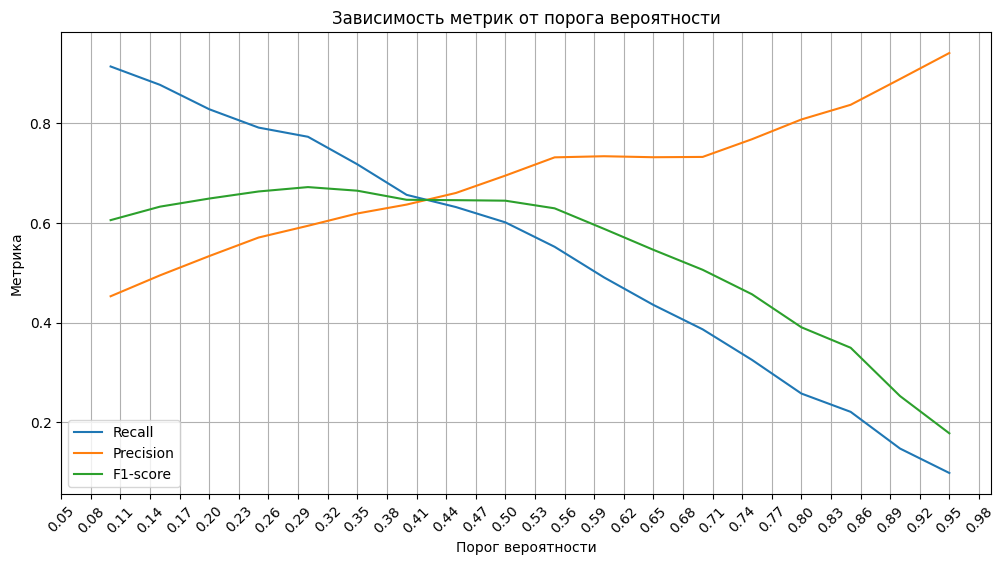

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, f1_scores, label="F1-score")

plt.title("Зависимость метрик от порога вероятности")
plt.xlabel("Порог вероятности")
plt.ylabel("Метрика")
plt.xticks(thresholds)
plt.xticks(np.arange(0.05, 1, 0.03), rotation=45)
plt.grid(True)
plt.legend()

best_threshold = thresholds[np.array(f1_scores).argmax()]
best_threshold

In [26]:
def get_scores(y_true: np.ndarray, y_pred: np.ndarray) -> pd.Series:
    """Вывод основных метрик."""
    return pd.Series({
        "precision": metrics.precision_score(y_true, y_pred),
        "recall": metrics.recall_score(y_true, y_pred),
        "f1": metrics.f1_score(y_true, y_pred),
    })

In [27]:
y_pred_optimal = (y_proba_pred >= best_threshold).astype(int)

print("Метрики по оптимально подобранному порогу:")
print(get_scores(y_test, y_pred_optimal))

y_pred_default = (y_proba_pred >= 0.5).astype(int)

print("Метрики по базовому порогу:")
print(get_scores(y_test, y_pred_default))

Метрики по оптимально подобранному порогу:
precision   0.59
recall      0.77
f1          0.67
dtype: float64
Метрики по базовому порогу:
precision   0.70
recall      0.60
f1          0.64
dtype: float64


**Вывод:**  
- модель с порогом `0.3` показывает лучшие результаты, чем со стандартным порогом `0.5`
- при таком пороге достигается лучший баланс параметров `precision|recall` в соответствии с требованими

## Часть 4. Калибровка

### Попытка улучшить модель путем различных калибровок

In [28]:
best_model_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear", 
    penalty="l1",
    C=1,
    random_state=42,
)

best_model_lr.fit(X_train_polynom, y_train)

calibrated_model = calibration.CalibratedClassifierCV(
    best_model_lr,
    method="sigmoid",
    cv=5,
)

y_train_pred_proba_base = best_model_lr.predict_proba(X_train_polynom)[:, 1]
y_test_pred_proba_base = best_model_lr.predict_proba(X_test_polynom)[:, 1]

calibrated_model.fit(X_train_polynom, y_train)
y_train_pred_proba_platt = calibrated_model.predict_proba(X_train_polynom)[:, 1]
y_test_pred_proba_platt = calibrated_model.predict_proba(X_test_polynom)[:, 1]

y_train_pred_platt = calibrated_model.predict(X_train_polynom)
y_test_pred_platt = calibrated_model.predict(X_test_polynom)

In [29]:
def plot_calibration_curve(
    y_train, y_train_pred_proba_base, y_train_pred_proba_calib
):
    prob_true_base, prob_pred_base = calibration.calibration_curve(
        y_train, y_train_pred_proba_base, n_bins=10
    )

    prob_true_calib, prob_pred_calib = calibration.calibration_curve(
        y_train, y_train_pred_proba_calib, n_bins=10
    )

    plt.plot(prob_pred_base, prob_true_base, marker="o", label="Base")
    plt.plot(prob_pred_calib, prob_true_calib, marker="o", label="Calibrated")
    plt.plot([0, 1], [0, 1], "--", label="Perfect")

    plt.xlabel("Predicted probability")
    plt.ylabel("True probability")
    plt.legend()
    plt.show()

Метрики после калибровки методом Платта
На обучающей выборке:
precision   0.79
recall      0.65
f1          0.71
dtype: float64
На тестовой выборке:
precision   0.71
recall      0.58
f1          0.64
dtype: float64


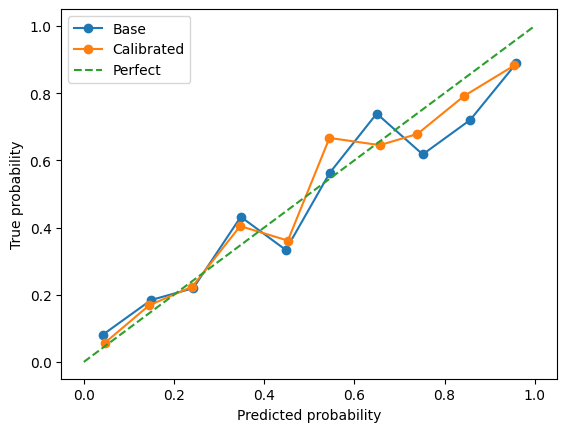

In [30]:
print("Метрики после калибровки методом Платта")
print("На обучающей выборке:")
print(get_scores(y_train, y_train_pred_platt))
print("На тестовой выборке:")
print(get_scores(y_test, y_test_pred_platt))

plot_calibration_curve(y_test, y_test_pred_proba_base, y_test_pred_proba_platt)

In [31]:
best_model_lr = linear_model.LogisticRegression(
    max_iter=1000,
    solver="liblinear", 
    penalty="l1",
    C=1,
    random_state=42,
)

best_model_lr.fit(X_train_polynom, y_train)

calibrated_model = calibration.CalibratedClassifierCV(
    best_model_lr,
    method="isotonic",
    cv=5,
)

calibrated_model.fit(X_train_polynom, y_train)
y_train_pred_isotonic = calibrated_model.predict(X_train_polynom)
y_test_pred_isotonic = calibrated_model.predict(X_test_polynom)

y_train_pred_proba_isotonic = calibrated_model.predict_proba(X_train_polynom)[:, 1]
y_test_pred_proba_isotonic = calibrated_model.predict_proba(X_test_polynom)[:, 1]

Метрики после калибровки изотонической регрессией
На обучающей выборке:
precision   0.82
recall      0.62
f1          0.70
dtype: float64
На тестовой выборке:
precision   0.73
recall      0.54
f1          0.62
dtype: float64


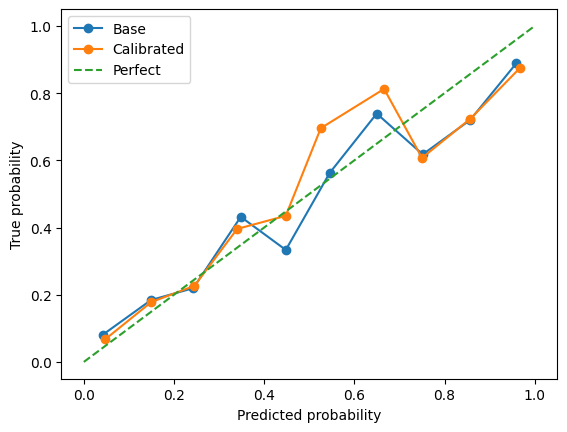

In [32]:
print("Метрики после калибровки изотонической регрессией")
print("На обучающей выборке:")
print(get_scores(y_train, y_train_pred_isotonic))
print("На тестовой выборке:")
print(get_scores(y_test, y_test_pred_isotonic))

plot_calibration_curve(y_test, y_test_pred_proba_base, y_test_pred_proba_isotonic)

**Вывод:**  
Использование калибровок не улучшило качество, а в последнем методе наоборот несколько ухудшило:
- метод Платта: `best f1 test 0.64` --> `calibrated f1 test 0.64` (на графике видно некоторое сглаживание откалиброванной прямой относительно идеальной)
- изотоническая регрессия: `best test f1 0.64` --> `calibrated f1 test 0.62`

Модель не стала лучше, интерпретируемость осталась на прежнем уровне